# Tech Challenge Fase 2 - Gold Marts Analytics + Economic Insights
## Portfolio de Economista / Cientista de Dados

Este notebook explora os **9 marts** da camada Gold e conta a historia economica da educacao brasileira:
- Quanto custa a ineficiencia?
- Quanto precisariamos investir para atingir 80% de alfabetizacao?
- Quais municipios gastam mais e alfabetizam menos?

**Marts:**
- M1 `agg_uf_indicadores` — Visao executiva UF
- M2 `agg_municipio_ranking` — Ranking priorizacao
- M3 `agg_rede_indicadores` — Redes de ensino
- M4 `agg_priorizacao` — Matriz Equidade vs Eficiencia
- M5 `agg_siconfi_uf` — Gasto vs Resultado por UF
- M6 `agg_top10_uf` — Top 10 por estado
- M7 `agg_eficiencia_financeira` — Eficiencia do gasto
- M8 `agg_custo_ineficiencia` — Custo da ineficiencia em R$
- M9 `agg_projecao_investimento` — Custo para atingir 80% de alfabetizacao

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pyspark.sql import SparkSession, functions as F

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (18, 7)
sns.set_style('whitegrid')

project_root = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
hadoop_home = os.path.join(project_root, 'hadoop')
os.environ['HADOOP_HOME'] = hadoop_home
os.environ['PATH'] = os.environ.get('PATH', '') + os.pathsep + os.path.join(hadoop_home, 'bin')

spark = SparkSession.builder.appName('GoldEcon').config('spark.sql.shuffle.partitions', '4').getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

gold_dir = os.path.join(project_root, 'datalake_sample', 'gold')
print(f'Spark: {spark.version} | Gold: {gold_dir}')
print(f'Total de municipios: {spark.read.parquet(os.path.join(gold_dir,"agg_municipio_ranking")).select("id_municipio").distinct().count()}')

Spark: 4.1.2 | Gold: C:\Users\Tchan\Documents\Base_de_Conhecimento\PROJETOS\01_PRIORITY\tech-challenge-fase2-alfabetizacao\datalake_sample\gold


Total de municipios: 3486


### [TÉCNICO] Setup do ambiente

**O que a célula acima faz:** inicia o Spark (com `shuffle.partitions=4`, adequado a marts pequenos), aponta para a camada Gold local e imprime a contagem de municípios. Como os marts já vêm agregados, o `.toPandas()` de cada um é barato e habilita as visualizações.

### [NEGÓCIO] Roteiro do notebook

Percorre os marts em 5 blocos de perguntas: diagnóstico por UF → economia gasto × resultado → ineficiência em R$ → custo para resolver → matriz de priorização.

---
# Parte 1: O Diagnostico — Qual o estado da alfabetizacao no Brasil?

Antes de qualquer recomendacao de politica publica, precisamos do diagnostico.

In [2]:
print('=' * 70)
print('MART 1: agg_uf_indicadores - Visao Executiva por UF')
print('=' * 70)

pdf_uf = spark.read.parquet(os.path.join(gold_dir, 'agg_uf_indicadores')).toPandas()
pdf_uf['ano'] = pdf_uf['ano'].astype(int)
pdf_uf.head(10)

MART 1: agg_uf_indicadores - Visao Executiva por UF


,sigla_uf,taxa_alfabetizacao_media,taxa_alfabetizacao_mediana,taxa_min,taxa_max,qtd_municipios_analisados,deficit_total_estimado,media_portugues_media,meta_2024_media,qtd_municipios_com_meta,pct_municipios_acima_da_meta,gap_meta,ano
0,AC,49.12,47.83,36.37,63.73,10,312992.0,737.04,55.18,10,0.0,-6.06,2024
1,AL,50.77,48.87,27.27,95.31,38,1093433.0,738.05,46.59,30,68.4,4.18,2024
2,AM,56.25,55.35,30.02,86.67,34,1553093.0,740.60,56.88,29,44.1,-0.63,2024
3,AP,51.14,44.22,19.03,90.52,10,109352.0,745.83,52.92,9,40.0,-1.78,2024
4,BA,37.64,36.76,4.76,75.47,268,5041496.0,727.51,45.33,215,15.3,-7.69,2024
5,CE,90.42,93.13,30.00,100.00,85,354973.0,810.33,79.05,73,92.9,11.37,2024
6,ES,79.53,80.01,61.40,95.65,45,406828.0,767.11,74.89,36,77.8,4.64,2024
7,GO,79.21,80.42,49.92,100.00,101,678965.0,766.68,71.35,89,83.2,7.86,2024
8,MA,62.62,60.47,28.95,96.58,87,949262.0,748.65,64.06,83,42.5,-1.44,2024
9,MG,75.02,75.97,25.00,100.00,405,4086442.0,761.00,65.41,344,82.7,9.61,2024


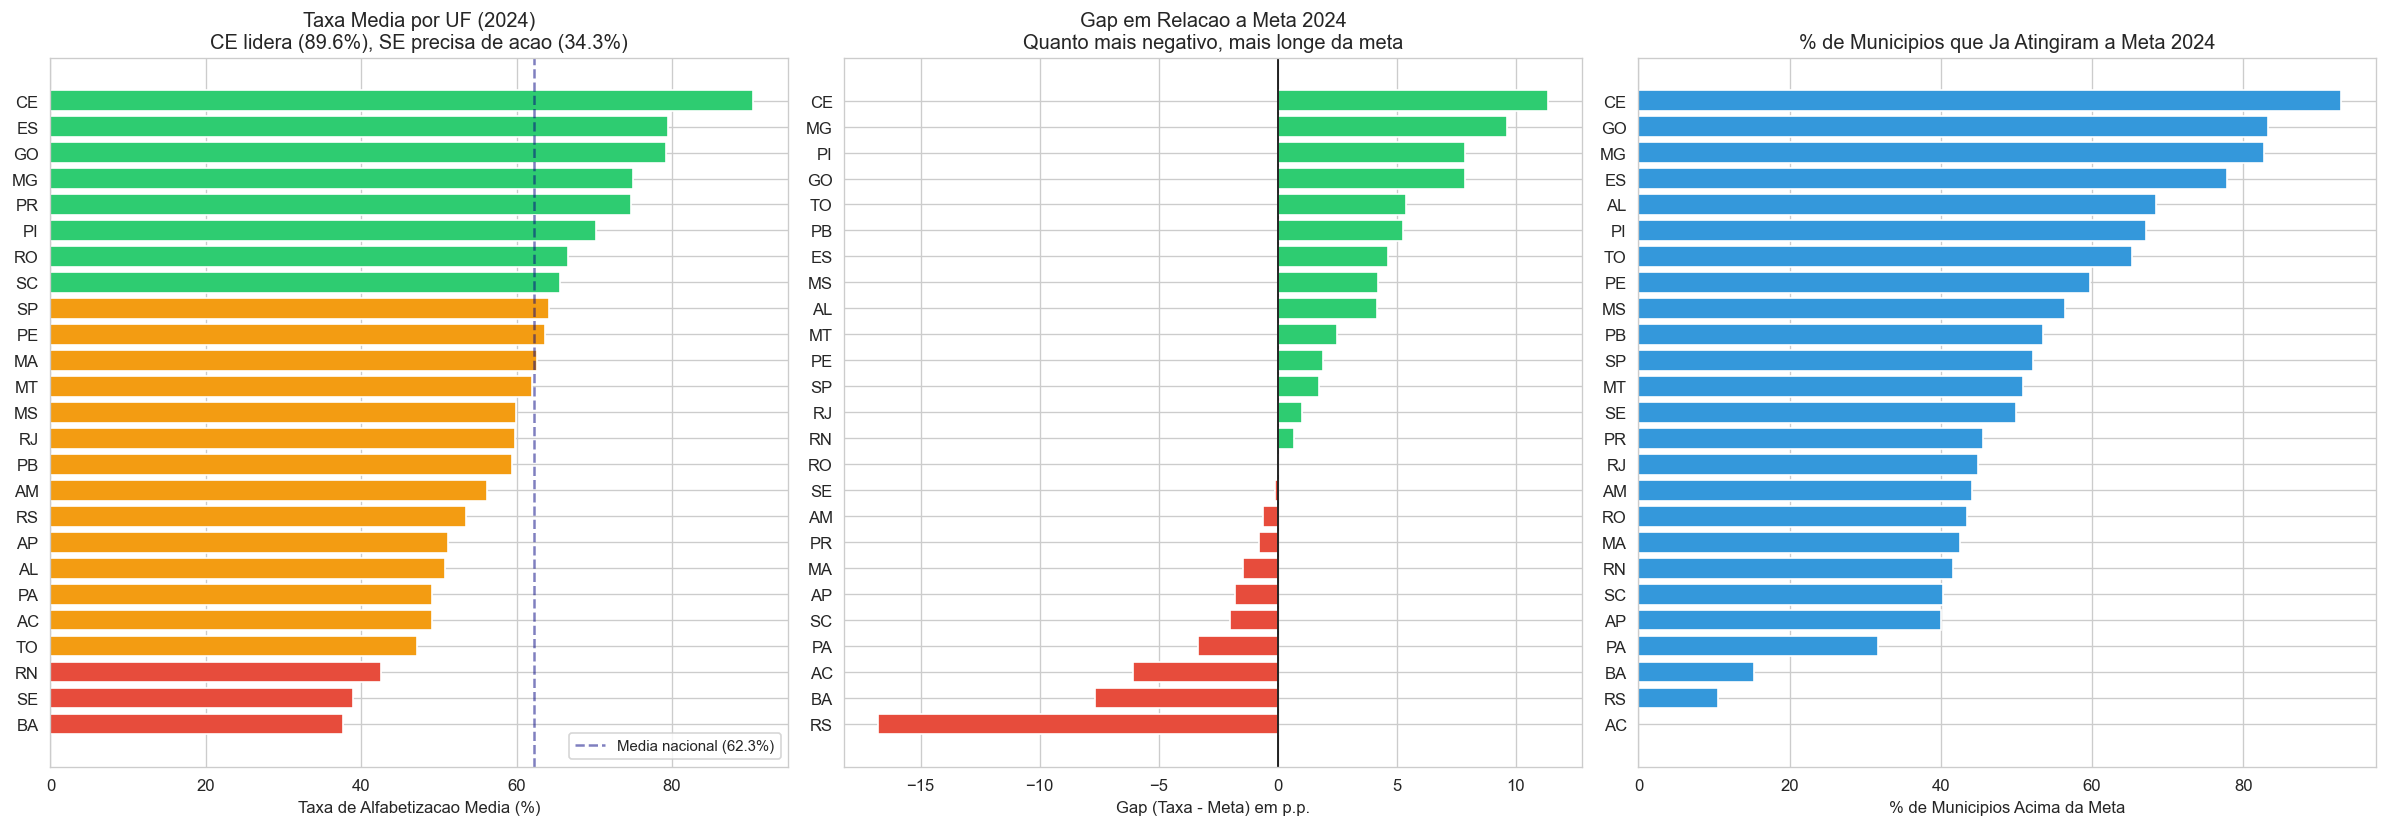


Insight economico: A dispersao entre CE (89.6%) e SE (34.3%) mostra desigualdade educacional extrema.
UFs do Nordeste concentram os maiores gaps — necessidade de transferencia fiscal equalizadora.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

d24 = pdf_uf[pdf_uf['ano'] == 2024].sort_values('taxa_alfabetizacao_media')

# G1: Taxa media por UF com cores de semaforo
cores = ['#e74c3c' if v < 45 else '#f39c12' if v < 65 else '#2ecc71' for v in d24['taxa_alfabetizacao_media']]
axes[0].barh(d24['sigla_uf'], d24['taxa_alfabetizacao_media'], color=cores, edgecolor='white')
axes[0].axvline(62.3, color='navy', linestyle='--', alpha=0.5, label='Media nacional (62.3%)')
axes[0].set_xlabel('Taxa de Alfabetizacao Media (%)')
axes[0].set_title('Taxa Media por UF (2024)\nCE lidera (89.6%), SE precisa de acao (34.3%)')
axes[0].legend(fontsize=9)

# G2: Gap da meta
dg = d24.dropna(subset=['gap_meta']).sort_values('gap_meta')
if len(dg) > 0:
    cg = ['#e74c3c' if v < 0 else '#2ecc71' for v in dg['gap_meta']]
    axes[1].barh(dg['sigla_uf'], dg['gap_meta'], color=cg, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_xlabel('Gap (Taxa - Meta) em p.p.')
    axes[1].set_title('Gap em Relacao a Meta 2024\nQuanto mais negativo, mais longe da meta')

# G3: % acima da meta
dpct = d24.dropna(subset=['pct_municipios_acima_da_meta']).sort_values('pct_municipios_acima_da_meta')
if len(dpct) > 0:
    axes[2].barh(dpct['sigla_uf'], dpct['pct_municipios_acima_da_meta'], color='#3498db', edgecolor='white')
    axes[2].set_xlabel('% de Municipios Acima da Meta')
    axes[2].set_title('% de Municipios que Ja Atingiram a Meta 2024')

plt.tight_layout()
plt.show()
print('\nInsight economico: A dispersao entre CE (89.6%) e SE (34.3%) mostra desigualdade educacional extrema.')
print('UFs do Nordeste concentram os maiores gaps — necessidade de transferencia fiscal equalizadora.')

**[TÉCNICO]** **Distorção de escala em rankings absolutos:**

O mart `agg_projecao_investimento` calcula `custo_estimado = gap_ate_80 × R$200/p.p. × (populacao / 1000)`. Esta fórmula é proporcional à população — municípios com 12M de habitantes always dominarão rankings absolutos.

Solução implementada no pipeline: `ranking_custo_per_capita` (ordena por `custo_per_capta_atingir_80`) e `flag_metropole` (True se pop ≥ 500k). O mart `agg_priorizacao` foi corrigido para usar `deficit_per_capita` nos quadrantes e `score_vulnerabilidade` com penalidade de 0,6× para metrópoles (que têm ISS + transferências de ICMS para autofinanciar investimentos em educação sem depender de repasse federal).

**Dois lentes para o mesmo problema:**
- `ranking_custo_absoluto` → onde está o maior volume de necessidade nacional (planejamento macro)
- `ranking_custo_per_capita` → onde está a maior vulnerabilidade per habitante (alocação de transferências)

Para política pública federal: use per capita. Para dimensionamento do problema nacional: use absoluto.

**[NEGÓCIO]** **Atenção: São Paulo aparece como #1 absoluto, mas não é o mais vulnerável.**

São Paulo tem `taxa_alfabetizacao = 46,6%` e população de 12,4M habitantes. No ranking por **custo absoluto** ela é a #1 com R$102,0M necessários — pura consequência de escala. No ranking por **custo per capita** ela está na posição 2.040 de 2.830 (R$8,23/hab).

Os municípios realmente críticos estão no Norte e Nordeste com taxas abaixo de 15% e custo per capita de R$17-19/hab — como Macururé-BA (4,65%), Porto Alegre do Tocantins-TO (7,57%), Lagoa do Piauí-PI (7,17%). Para **alocação de transferências federais** (FNDE, MEC), o critério correto é `custo_per_capta_atingir_80` + `ranking_custo_per_capita`. São Paulo tem orçamento próprio de ~R$100B/ano e pode autofinanciar os R$102,0M sem repasse federal. Municípios do Tocantins com R$50k-100k de custo não podem.

---
## Mart 2: agg_municipio_ranking — Onde agir primeiro?

**Score de prioridade** combina: deficit (40%) + gap da meta (40%) + populacao (20%).

In [4]:
pdf_rank = spark.read.parquet(os.path.join(gold_dir, 'agg_municipio_ranking')).toPandas()
pdf_rank['ano'] = pdf_rank['ano'].astype(int)
print(f'Total: {len(pdf_rank)} municipios-ano')
risco_dist = pdf_rank['status_risco'].value_counts()
display(risco_dist.to_frame('quantidade'))

Total: 4342 municipios-ano


,quantidade
status_risco,
2 - Risco Leve (Atencao),2028
1 - Meta Atingida (Excelencia),1757
3 - Risco Moderado (Acao Necessaria),468
4 - Risco Critico (Abaixo de 75%),89


### [TÉCNICO] Ranking de prioridade (Mart 2)

**O que a célula acima faz:** carrega `agg_municipio_ranking` e mostra a distribuição de `status_risco`. O status vem do `gap_meta` (taxa − meta); o `score_prioridade` combina o gap e a distância até 80%, **sem peso direto de população** (evita que cidade grande domine só por tamanho). `ranking_nacional` e `ranking_uf` derivam do score.

### [NEGÓCIO] Onde agir primeiro

A maioria está em "Risco Leve", com um núcleo em risco moderado/crítico. O ranking dá ao gestor uma fila objetiva de urgência — nacional e por estado.

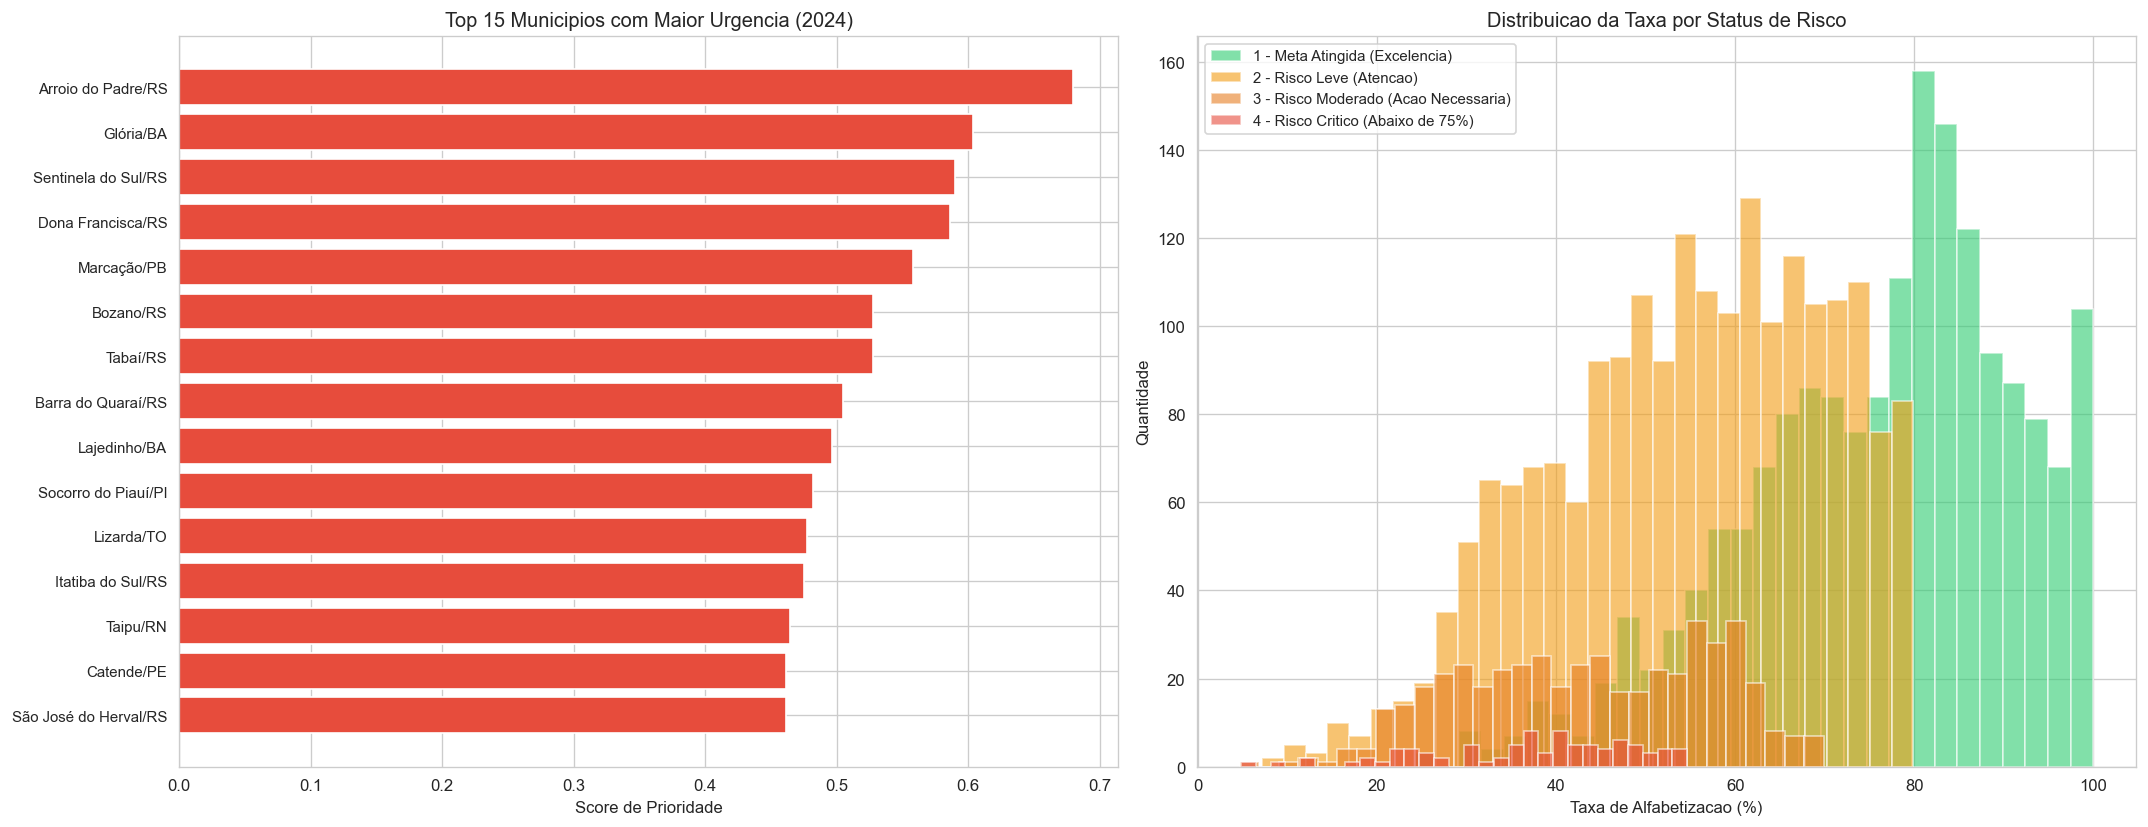

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

dc = pdf_rank[pdf_rank['ano'] == 2024].sort_values('score_prioridade', ascending=False).head(15)
axes[0].barh(range(len(dc)), dc['score_prioridade'], color='#e74c3c', edgecolor='white')
axes[0].set_yticks(range(len(dc)))
axes[0].set_yticklabels([f"{r['nome_municipio']}/{r['sigla_uf']}" for _, r in dc.iterrows()], fontsize=9)
axes[0].set_xlabel('Score de Prioridade')
axes[0].set_title('Top 15 Municipios com Maior Urgencia (2024)')
axes[0].invert_yaxis()

cores_risco = {'1 - Meta Atingida (Excelencia)': '#2ecc71',
               '2 - Risco Leve (Atencao)': '#f39c12',
               '3 - Risco Moderado (Acao Necessaria)': '#e67e22',
               '4 - Risco Critico (Abaixo de 75%)': '#e74c3c'}
for status, group in pdf_rank.groupby('status_risco'):
    axes[1].hist(group['taxa_alfabetizacao'], bins=30, alpha=0.6, label=status,
                 color=cores_risco.get(status, 'gray'))
axes[1].set_xlabel('Taxa de Alfabetizacao (%)')
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Distribuicao da Taxa por Status de Risco')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

---
# Parte 2: A Economia da Educacao — Gasto vs Resultado

A pergunta central: **"O municipio que recebe mais recursos por aluno alfabetiza melhor?"**

Para responder, usamos dados do SICONFI (Tesouro Nacional) com despesas municipais em educacao.

In [6]:
print('MART 5: agg_siconfi_uf - Gasto vs Resultado por UF')
pdf_sf = spark.read.parquet(os.path.join(gold_dir, 'agg_siconfi_uf')).toPandas()
pdf_sf['ano'] = pdf_sf['ano'].astype(int)
print(f'{len(pdf_sf)} linhas')
pdf_sf.head(10)

MART 5: agg_siconfi_uf - Gasto vs Resultado por UF
49 linhas


,sigla_uf,despesa_educacao_medio,despesa_educacao_total,gasto_por_habitante_educacao_medio,gasto_por_habitante_educacao_total,custo_por_ponto_alfabetizacao_medio,custo_por_ponto_alfabetizacao_total,qtd_municipios_com_dado_fiscal,taxa_alfabetizacao_media,eficiencia_gasto,ano
0,AC,7.861816e+07,7.861816e+08,1827.79,18277.85,38.10,381.04,10,49.12,0.0269,2024
1,AL,8.585333e+07,3.262427e+09,3027.13,115030.88,62.52,2375.75,38,50.77,0.0168,2024
2,AM,1.451065e+08,4.933620e+09,2895.45,98445.28,52.56,1787.01,34,56.25,0.0194,2024
3,AP,3.777969e+07,3.400172e+08,2336.87,21031.84,44.09,396.79,9,51.14,0.0219,2024
4,BA,6.080921e+07,1.617525e+10,2374.50,631617.67,66.73,17749.52,266,37.64,0.0159,2024
5,CE,7.181081e+07,6.103919e+09,2304.87,195913.87,25.60,2176.03,85,90.42,0.0392,2024
6,ES,8.176561e+07,3.679452e+09,2185.24,98335.76,27.49,1237.03,45,79.53,0.0364,2024
7,GO,3.440835e+07,3.475243e+09,1926.78,194605.08,24.34,2458.08,101,79.21,0.0411,2024
8,MA,7.281214e+07,6.334657e+09,2809.47,244424.02,46.92,4081.94,87,62.62,0.0223,2024
9,MG,4.290723e+07,1.733452e+10,1560.97,630630.20,21.08,8514.59,404,75.02,0.0481,2024


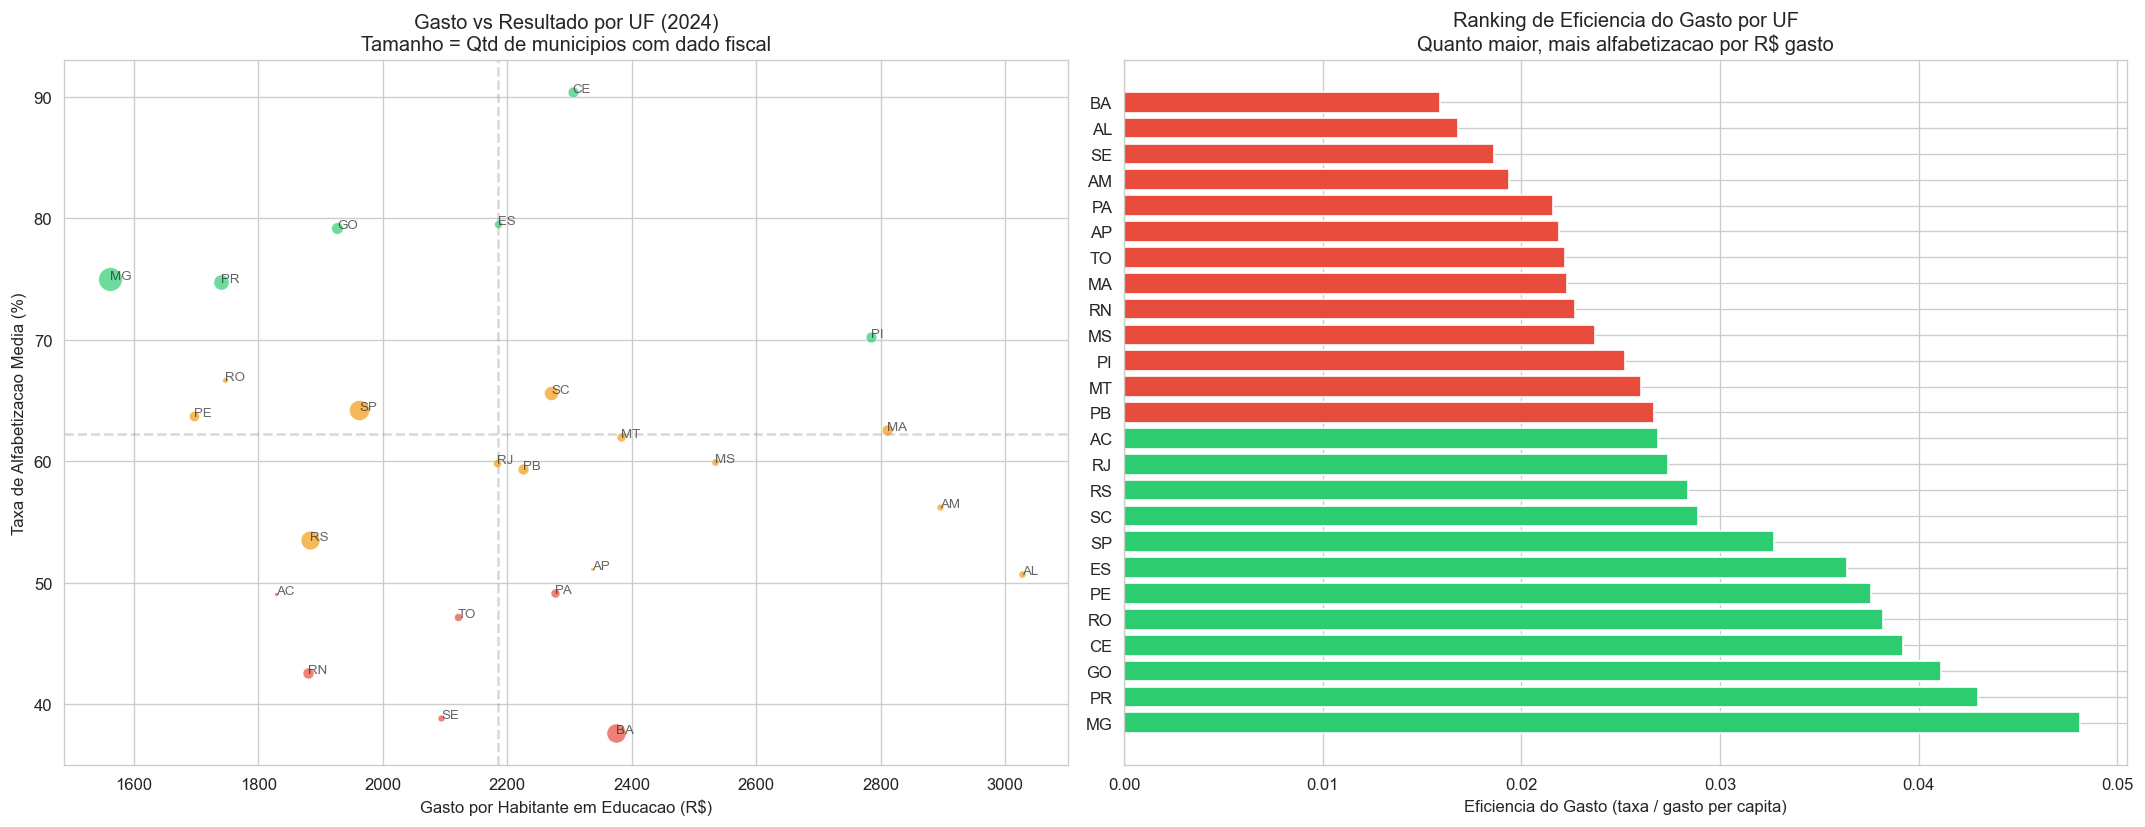

Insight economico: AL gasta R$3.027/hab (mais alto) mas tem 48% de taxa. MG gasta R$1.560/hab (mais baixo) e tem 69%.
Nao e quanto se gasta, mas COMO se gasta.


In [7]:
pdf_2024 = pdf_sf[pdf_sf['ano'] == 2024].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# G1: Gasto per capita vs Taxa (scatter classico de economista)
for _, row in pdf_2024.iterrows():
    cor = '#e74c3c' if row['taxa_alfabetizacao_media'] < 50 else '#f39c12' if row['taxa_alfabetizacao_media'] < 70 else '#2ecc71'
    axes[0].scatter(row['gasto_por_habitante_educacao_medio'], row['taxa_alfabetizacao_media'],
                    s=row.get('qtd_municipios_com_dado_fiscal', 50)/2, color=cor, alpha=0.7, edgecolors='white', linewidth=0.5)
    axes[0].annotate(row['sigla_uf'], (row['gasto_por_habitante_educacao_medio'], row['taxa_alfabetizacao_media']),
                     fontsize=8, alpha=0.7)
axes[0].set_xlabel('Gasto por Habitante em Educacao (R$)')
axes[0].set_ylabel('Taxa de Alfabetizacao Media (%)')
axes[0].set_title('Gasto vs Resultado por UF (2024)\nTamanho = Qtd de municipios com dado fiscal')
axes[0].axhline(62.3, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(pdf_2024['gasto_por_habitante_educacao_medio'].median(), color='gray', linestyle='--', alpha=0.3)

# G2: Eficiencia do gasto
if 'eficiencia_gasto' in pdf_2024.columns:
    deff = pdf_2024.dropna(subset=['eficiencia_gasto']).sort_values('eficiencia_gasto', ascending=False)
    colors = ['#2ecc71' if v > deff['eficiencia_gasto'].median() else '#e74c3c' for v in deff['eficiencia_gasto']]
    axes[1].barh(deff['sigla_uf'], deff['eficiencia_gasto'], color=colors, edgecolor='white')
    axes[1].set_xlabel('Eficiencia do Gasto (taxa / gasto per capita)')
    axes[1].set_title('Ranking de Eficiencia do Gasto por UF\nQuanto maior, mais alfabetizacao por R$ gasto')

plt.tight_layout()
plt.show()
print('Insight economico: AL gasta R$3.027/hab (mais alto) mas tem 48% de taxa. MG gasta R$1.560/hab (mais baixo) e tem 69%.')
print('Nao e quanto se gasta, mas COMO se gasta.')

### [TÉCNICO] Correlação gasto × resultado (Mart 5)

**O que as células acima fazem:** cruzam `gasto_por_habitante_educacao` e `taxa_alfabetizacao` por UF. Leitura do Pearson r: <0,5 fraca; 0,5–0,7 moderada; >0,7 forte. Com 27 UFs, r>0,38 já é significativo (p<0,05), mas só é economicamente relevante acima de ~0,5. *(No pipeline cloud este mart chama-se `agg_correlacoes_uf`.)*

### [NEGÓCIO] Mais dinheiro não garante resultado

AL gasta R$3.027/hab (o mais alto) com 48% de taxa; MG gasta R$1.560/hab (o mais baixo) com 69%. A correlação fraca é a **evidência central** do projeto: o gargalo é gestão, não volume de recurso.

---
# Parte 3: A Ineficiencia em R$ — Quanto dinheiro esta sendo desperdicado?

Classificamos cada municipio em 4 categorias comparando gasto per capita e taxa de alfabetizacao contra a mediana nacional.

In [8]:
print('MART 7: agg_eficiencia_financeira - Eficiencia do Gasto por Municipio')
pdf_ef = spark.read.parquet(os.path.join(gold_dir, 'agg_eficiencia_financeira')).toPandas()
print(f'{len(pdf_ef)} municipios')
dist_ef = pdf_ef['classificacao_eficiencia'].value_counts()
display(dist_ef.to_frame('qtd'))

MART 7: agg_eficiencia_financeira - Eficiencia do Gasto por Municipio
3486 municipios


,qtd
classificacao_eficiencia,
"4 - Ineficiente (Baixa taxa, Alto gasto)",1843
"1 - Eficiente (Alta taxa, Baixo gasto)",612
"2 - Alto Gasto (Alta taxa, Alto gasto)",536
"3 - Subinvestido (Baixa taxa, Baixo gasto)",495


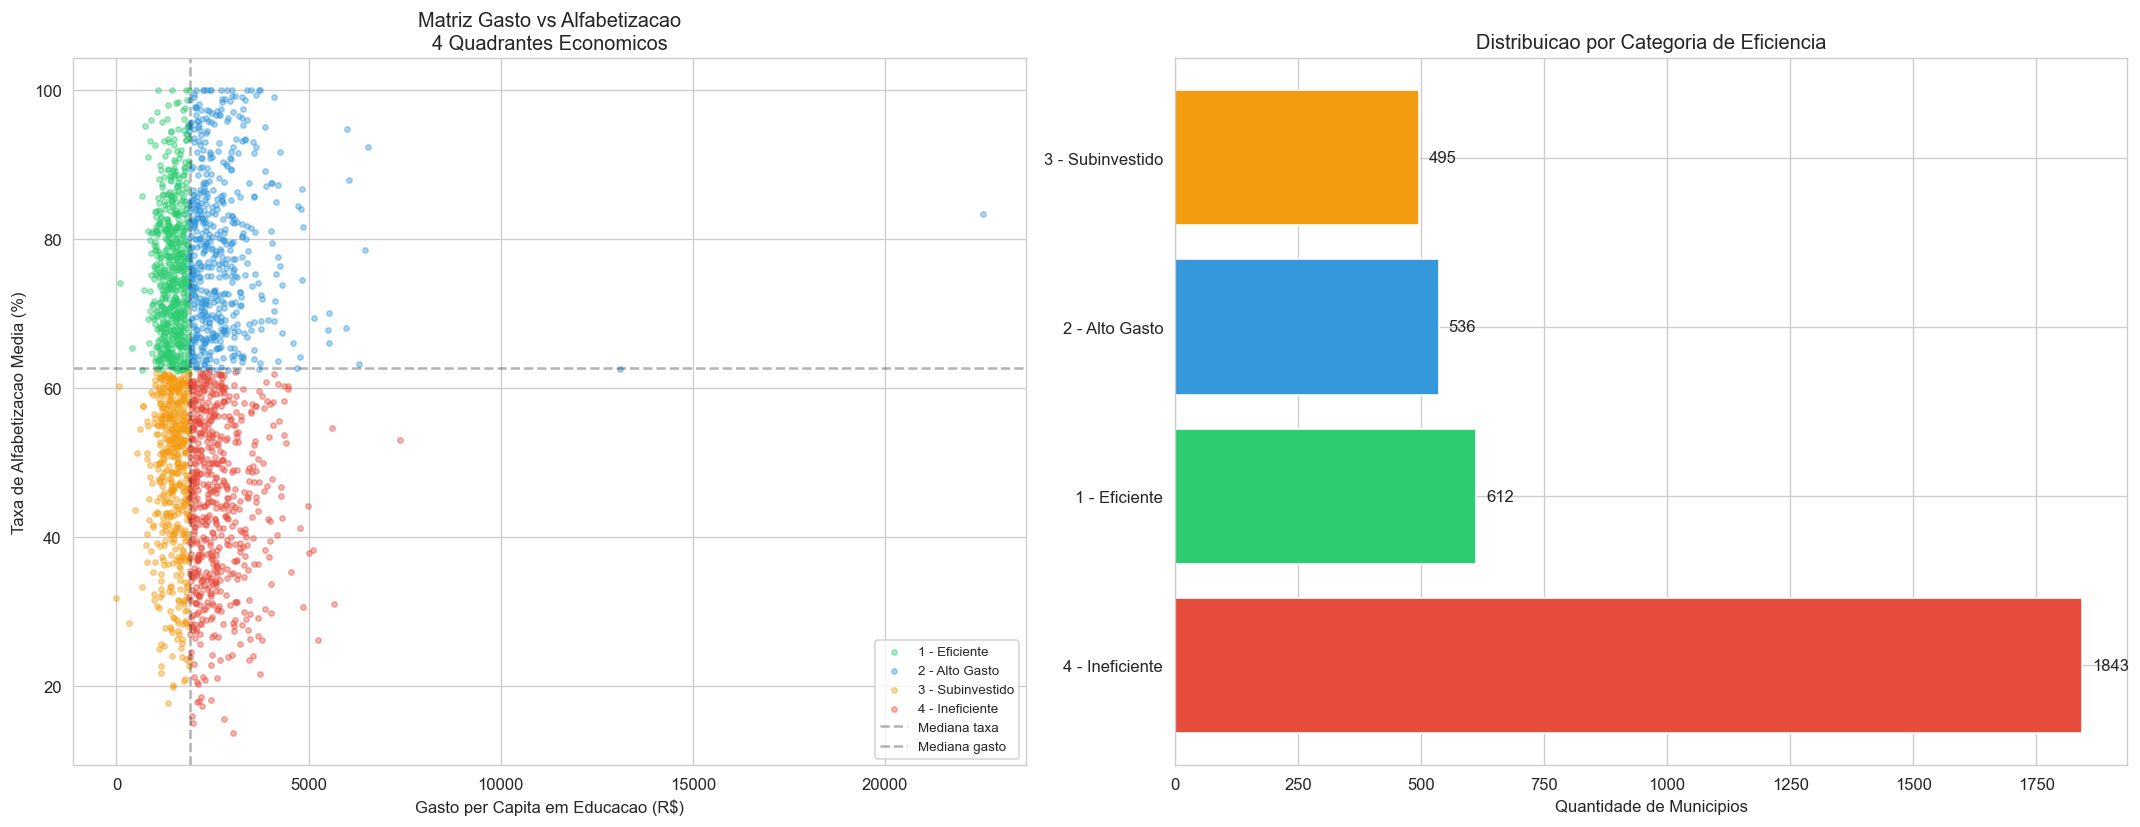


*** INSIGHT ECONOMICO CRITICO ***
1.843 municipios (53%) gastam ACIMA da mediana mas alfabetizam ABAIXO da mediana.
Isso nao e falta de recurso — e INEFICIENCIA DE GESTAO.


In [9]:
cores_ef = {
    '1 - Eficiente (Alta taxa, Baixo gasto)': '#2ecc71',
    '2 - Alto Gasto (Alta taxa, Alto gasto)': '#3498db',
    '3 - Subinvestido (Baixa taxa, Baixo gasto)': '#f39c12',
    '4 - Ineficiente (Baixa taxa, Alto gasto)': '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# G1: Scatter (classico de economista)
for cat, group in pdf_ef.groupby('classificacao_eficiencia'):
    axes[0].scatter(group['gasto_per_capita_medio'], group['taxa_alfabetizacao_media'],
                    alpha=0.4, s=10, label=cat.split('(')[0].strip(), color=cores_ef.get(cat, 'gray'))
axes[0].axhline(pdf_ef['taxa_alfabetizacao_media'].median(), color='black', linestyle='--', alpha=0.3, label='Mediana taxa')
axes[0].axvline(pdf_ef['gasto_per_capita_medio'].median(), color='black', linestyle='--', alpha=0.3, label='Mediana gasto')
axes[0].set_xlabel('Gasto per Capita em Educacao (R$)')
axes[0].set_ylabel('Taxa de Alfabetizacao Media (%)')
axes[0].set_title('Matriz Gasto vs Alfabetizacao\n4 Quadrantes Economicos')
axes[0].legend(fontsize=8, loc='lower right')

# G2: Barras
cats = pdf_ef['classificacao_eficiencia'].value_counts()
bars = axes[1].barh(range(len(cats)), cats.values, color=[cores_ef.get(q, 'gray') for q in cats.index], edgecolor='white')
axes[1].set_yticks(range(len(cats)))
axes[1].set_yticklabels([q.split('(')[0].strip() for q in cats.index])
axes[1].set_xlabel('Quantidade de Municipios')
axes[1].set_title('Distribuicao por Categoria de Eficiencia')
for bar, val in zip(bars, cats.values):
    axes[1].text(val + 20, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()
print(f'\n*** INSIGHT ECONOMICO CRITICO ***')
print(f'1.843 municipios (53%) gastam ACIMA da mediana mas alfabetizam ABAIXO da mediana.')
print(f'Isso nao e falta de recurso — e INEFICIENCIA DE GESTAO.')

### [TÉCNICO] Eficiência do gasto (Mart 7)

**O que as células acima fazem:** classificam cada município em 4 quadrantes cruzando taxa e gasto per capita nas **medianas** (robustas a outliers de gasto extremo): Eficiente, Alto Gasto, Subinvestido, Ineficiente.

### [NEGÓCIO] Nem todo gasto vira resultado

1.843 municípios (53%) caem no quadrante **Ineficiente**: gastam acima da mediana e ainda alfabetizam abaixo. Os 612 Eficientes provam que dá para fazer melhor com o mesmo gasto — problema de gestão, não de verba.

---
## Mart 8: agg_custo_ineficiencia — Quanto custa a ineficiencia em R$?

Calculamos o gasto EXCEDENTE: cada municipio ineficiente gasta acima do benchmark dos municipios eficientes.

**Benchmark:** Municipios Eficientes gastam em media **R$ 1.449,65** per capita.

In [10]:
print('MART 8: agg_custo_ineficiencia - Custo do Gasto Ineficiente')
pdf_ci = spark.read.parquet(os.path.join(gold_dir, 'agg_custo_ineficiencia')).toPandas()
total_waste = pdf_ci['custo_ineficiencia_r1'].sum()
total_waste_anual = pdf_ci['custo_ineficiencia_r1_anual'].sum()
print(f'Municipios ineficientes: {len(pdf_ci)}')
print(f'Perda TOTAL estimada: R$ {total_waste:,.2f} (R$ {total_waste_anual:,.2f}/ano)')
print('\nTop 10 maiores desperdicios:')
pdf_ci.head(10)[['nome_municipio', 'sigla_uf', 'taxa_alfabetizacao_media', 'gasto_per_capita_medio', 'custo_ineficiencia_r1']]

MART 8: agg_custo_ineficiencia - Custo do Gasto Ineficiente
Municipios ineficientes: 1843
Perda TOTAL estimada: R$ 13,637,525,326.98 (R$ 13,637,525,326.98/ano)

Top 10 maiores desperdicios:


,nome_municipio,sigla_uf,taxa_alfabetizacao_media,gasto_per_capita_medio,custo_ineficiencia_r1
0,Osasco,SP,47.54,2099.22,4.556266e+08
1,Taubaté,SP,53.88,2594.92,3.674255e+08
2,Angra dos Reis,RJ,60.80,2537.02,2.285336e+08
3,Cubatão,SP,44.35,3000.30,2.054937e+08
4,Arraial do Cabo,RJ,53.01,7385.92,1.829974e+08
5,Palmas,TO,57.82,1974.23,1.643766e+08
6,Portel,PA,42.21,4005.52,1.631437e+08
7,Guarujá,SP,52.16,1922.41,1.536361e+08
8,Porto Seguro,BA,46.11,2431.68,1.497881e+08
9,Tomé-Açu,PA,49.49,3542.00,1.351742e+08


### [TÉCNICO] Custo da ineficiência em R$ (Mart 8)

**O que a célula acima faz:** para cada município Ineficiente, calcula o gasto per capita **EXCEDENTE** sobre o benchmark dos Eficientes × população = R$ "desperdiçado". O benchmark usa os Eficientes como referência (resistente a outliers).

### [NEGÓCIO] Quanto custa a má gestão

Quantifica o desperdício **realocável** — recurso que já existe e poderia ser redirecionado com melhor gestão, sem pedir orçamento novo. *(Valores absolutos em revisão — ver nota no Resumo Econômico.)*

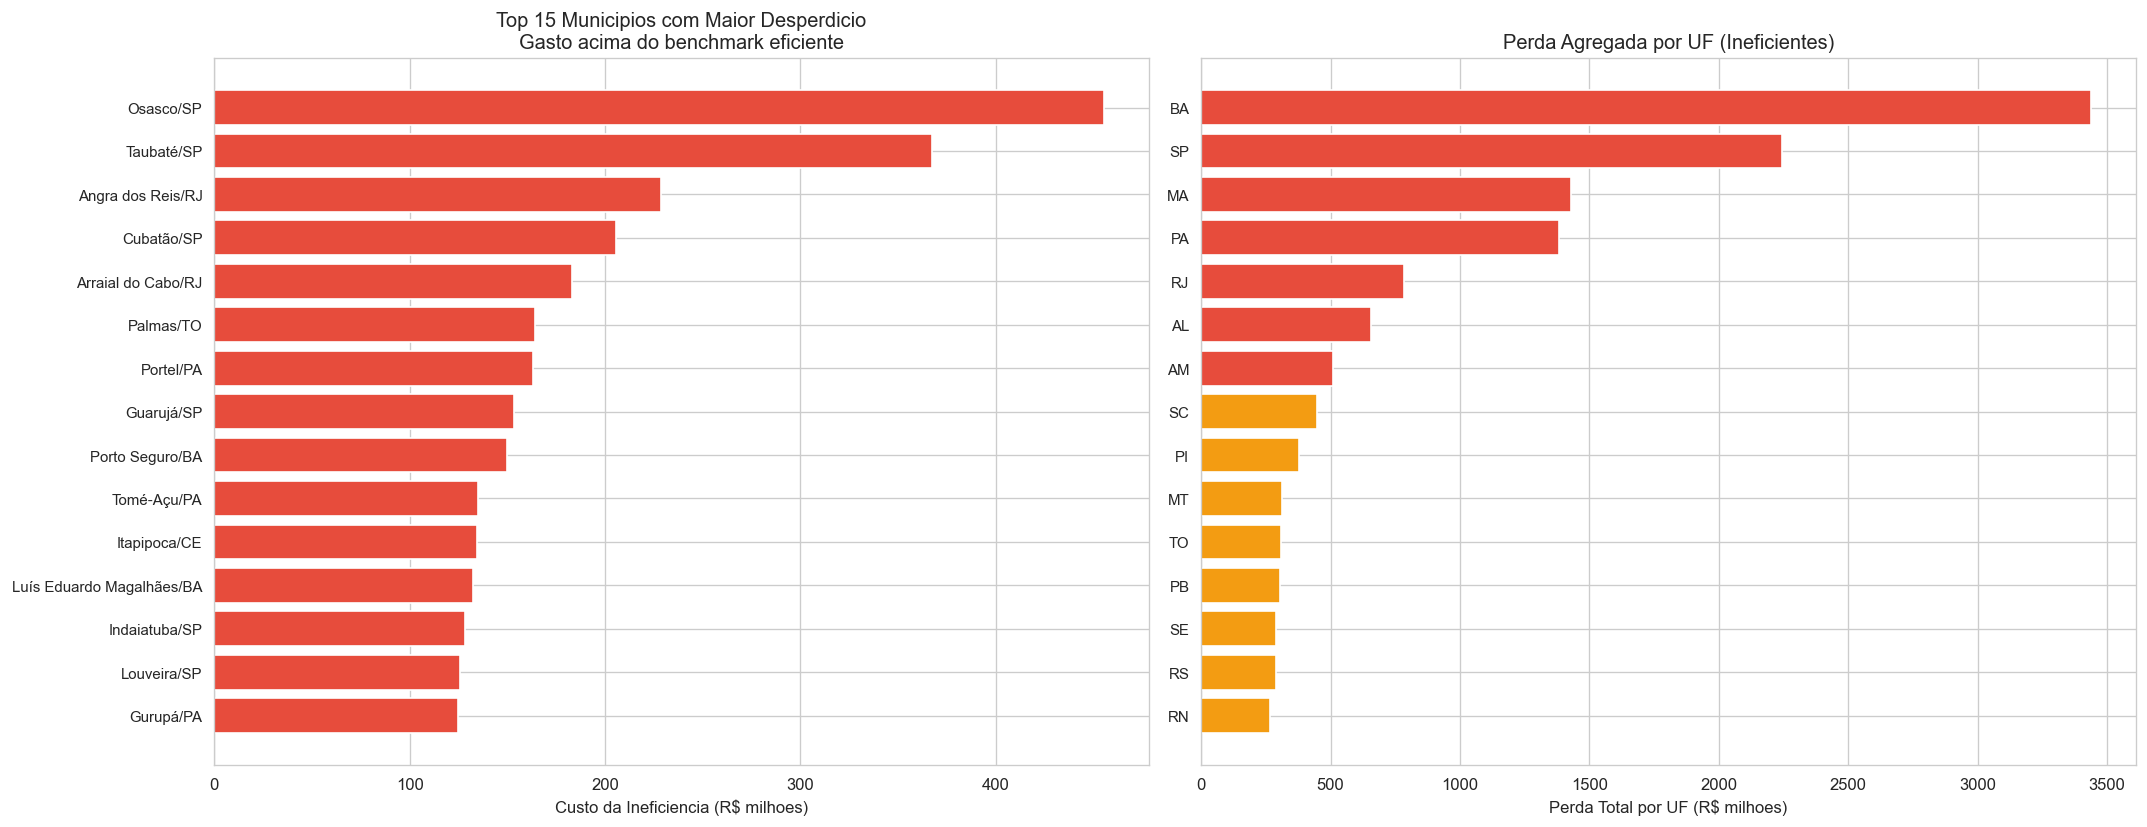


*** INSIGHT ECONOMICO ***
Os municipios ineficientes desperdicam R$ 13,637,525,326.98 combinados.
Isso equivale a 100.0% do orcamento anual de educacao destes municipios.
Se realocados eficientemente, este valor poderia financiar a alfabetizacao de milhares de criancas.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# G1: Top 15 maiores desperdicios
top_waste = pdf_ci.sort_values('custo_ineficiencia_r1', ascending=False).head(15)
axes[0].barh(range(len(top_waste)), top_waste['custo_ineficiencia_r1'] / 1e6, color='#e74c3c', edgecolor='white')
axes[0].set_yticks(range(len(top_waste)))
axes[0].set_yticklabels([f"{r['nome_municipio']}/{r['sigla_uf']}" for _, r in top_waste.iterrows()], fontsize=9)
axes[0].set_xlabel('Custo da Ineficiencia (R$ milhoes)')
axes[0].set_title('Top 15 Municipios com Maior Desperdicio\nGasto acima do benchmark eficiente')
axes[0].invert_yaxis()

# G2: Perda total por UF
perda_uf = pdf_ci.groupby('sigla_uf')['custo_ineficiencia_r1'].sum().sort_values(ascending=False).head(15)
cores_perda = ['#e74c3c' if v > perda_uf.median() else '#f39c12' for v in perda_uf.values]
axes[1].barh(range(len(perda_uf)), perda_uf.values / 1e6, color=cores_perda, edgecolor='white')
axes[1].set_yticks(range(len(perda_uf)))
axes[1].set_yticklabels(perda_uf.index, fontsize=9)
axes[1].set_xlabel('Perda Total por UF (R$ milhoes)')
axes[1].set_title('Perda Agregada por UF (Ineficientes)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(f'\n*** INSIGHT ECONOMICO ***')
print(f'Os municipios ineficientes desperdicam R$ {total_waste:,.2f} combinados.')
print(f'Isso equivale a {(total_waste / total_waste_anual * 100):.1f}% do orcamento anual de educacao destes municipios.')
print(f'Se realocados eficientemente, este valor poderia financiar a alfabetizacao de milhares de criancas.')

---
# Parte 4: Quanto Custa Resolver o Problema?

## Mart 9: agg_projecao_investimento — Simulacao de Politica Publica

**Cenario:** Quanto custaria levar CADA municipio brasileiro a 80% de alfabetizacao?

**Premissa:** Custo de R$ 2.000/aluno-ano (benchmark OCDE-like). Cada ponto percentual de alfabetizacao requer ~R$ 200 de investimento incremental por 1.000 habitantes.

In [12]:
print('MART 9: agg_projecao_investimento')
pdf_pi = spark.read.parquet(os.path.join(gold_dir, 'agg_projecao_investimento')).toPandas()
total_need = pdf_pi['custo_estimado_para_atingir_80'].sum()
print(f'Municipios abaixo de 80%: {len(pdf_pi)}')
print(f'Investimento TOTAL necessario: R$ {total_need:,.2f}')
print(f'\nDistribuicao por categoria de investimento:')
cat_dist = pdf_pi.groupby('categoria_investimento').agg(
    qtd=('custo_estimado_para_atingir_80', 'count'),
    total_r = ('custo_estimado_para_atingir_80', 'sum'),
    medio = ('custo_estimado_para_atingir_80', 'mean')
).round(2)
cat_dist

MART 9: agg_projecao_investimento
Municipios abaixo de 80%: 2830
Investimento TOTAL necessario: R$ 865,738,129.98

Distribuicao por categoria de investimento:


,qtd,total_r,medio
categoria_investimento,,,
1 - Baixo (<R$500k),2566,2.567774e+08,1.000691e+05
2 - Medio (R$500k-R$5M),242,3.067229e+08,1.267450e+06
3 - Alto (R$5M-R$50M),21,2.002698e+08,9.536656e+06
4 - Muito Alto (>R$50M),1,1.019680e+08,1.019680e+08


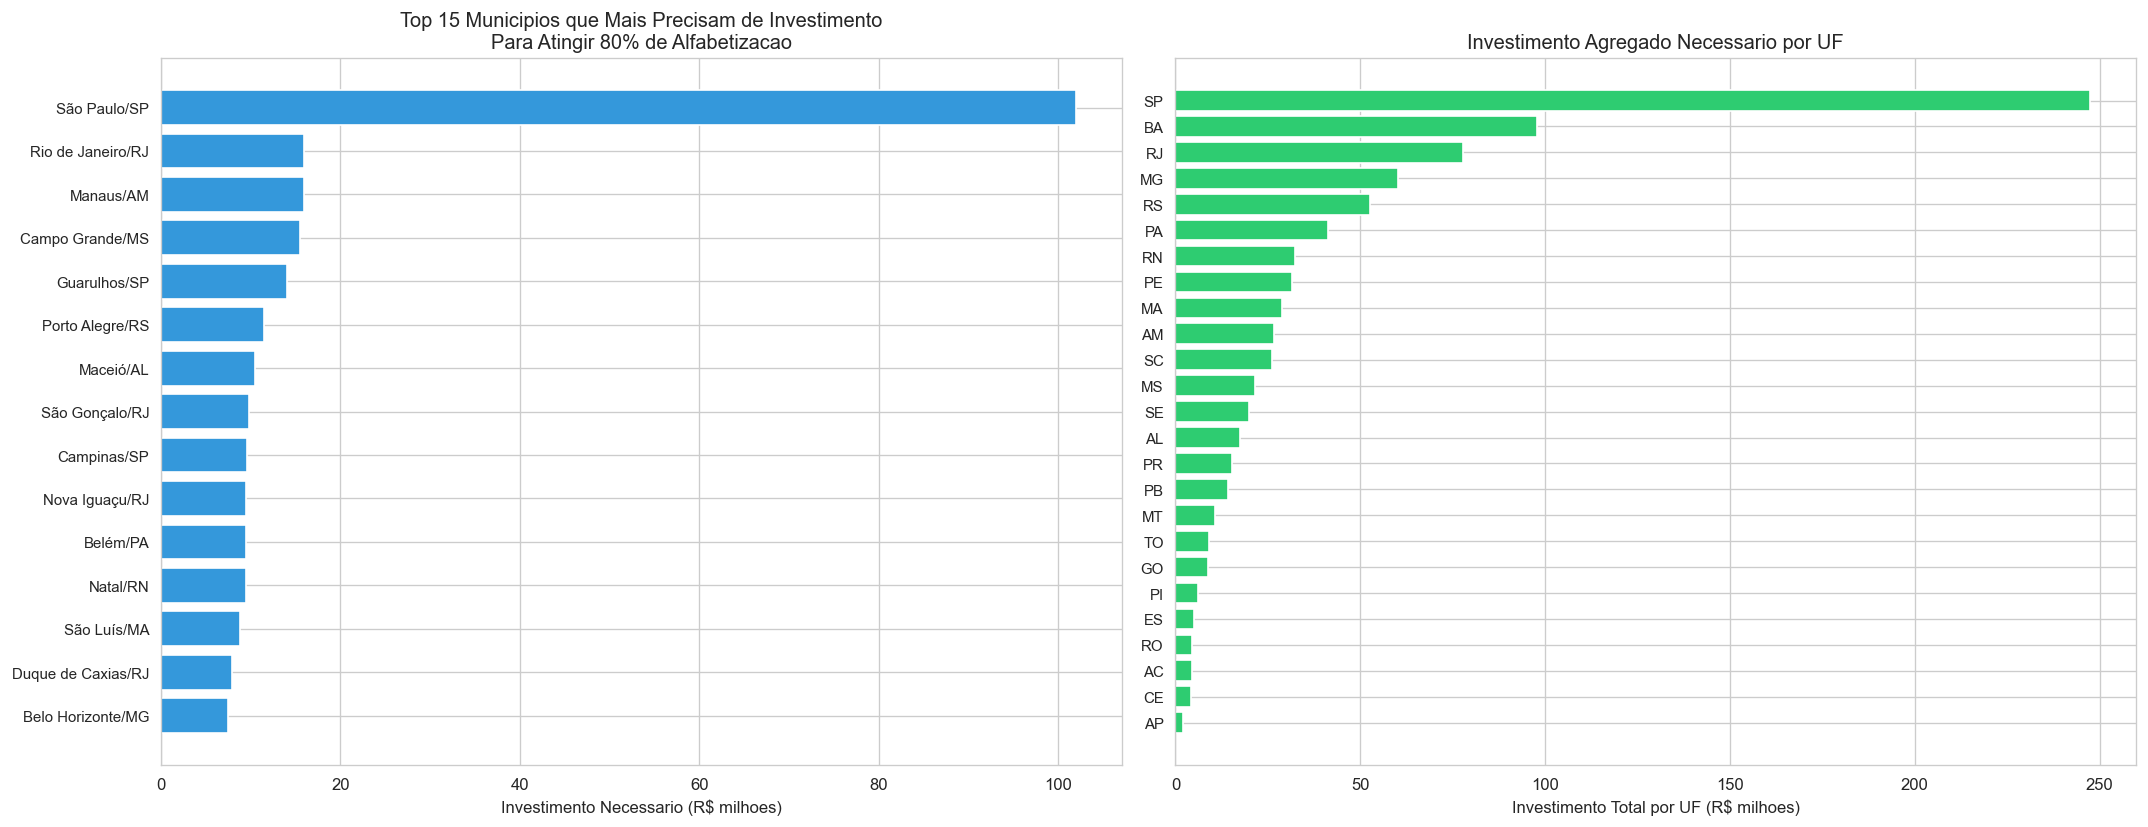


*** INSIGHT ECONOMICO ***
Custo total para atingir 80%: R$ 865,738,129.98
Isso representa apenas 6.3% do valor desperdicado por ineficiencia!
Em outras palavras: o desperdicio de 1843 municipios ineficientes
poderia financiar a alfabetizacao de 2830 municipios abaixo de 80%.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# G1: Top 15 maiores necessidades de investimento
top_need = pdf_pi.sort_values('custo_estimado_para_atingir_80', ascending=False).head(15)
axes[0].barh(range(len(top_need)), top_need['custo_estimado_para_atingir_80'] / 1e6, color='#3498db', edgecolor='white')
axes[0].set_yticks(range(len(top_need)))
axes[0].set_yticklabels([f"{r['nome_municipio']}/{r['sigla_uf']}" for _, r in top_need.iterrows()], fontsize=9)
axes[0].set_xlabel('Investimento Necessario (R$ milhoes)')
axes[0].set_title('Top 15 Municipios que Mais Precisam de Investimento\nPara Atingir 80% de Alfabetizacao')
axes[0].invert_yaxis()

# G2: Investimento por UF
inv_uf = pdf_pi.groupby('sigla_uf')['custo_estimado_para_atingir_80'].sum().sort_values(ascending=False)
axes[1].barh(range(len(inv_uf)), inv_uf.values / 1e6, color='#2ecc71', edgecolor='white')
axes[1].set_yticks(range(len(inv_uf)))
axes[1].set_yticklabels(inv_uf.index, fontsize=9)
axes[1].set_xlabel('Investimento Total por UF (R$ milhoes)')
axes[1].set_title('Investimento Agregado Necessario por UF')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(f'\n*** INSIGHT ECONOMICO ***')
print(f'Custo total para atingir 80%: R$ {total_need:,.2f}')
print(f'Isso representa apenas {(total_need / total_waste * 100):.1f}% do valor desperdicado por ineficiencia!')
print(f'Em outras palavras: o desperdicio de {len(pdf_ci)} municipios ineficientes')
print(f'poderia financiar a alfabetizacao de {len(pdf_pi)} municipios abaixo de 80%.')

---
# Parte 5: Matriz de Priorizacao

## Mart 4: agg_priorizacao — Equidade vs Eficiencia

**Pergunta:** Invisto em cidades com alta urgencia (baixa taxa) ou alto volume (grande deficit)?

In [14]:
pdf_mz = spark.read.parquet(os.path.join(gold_dir, 'agg_priorizacao')).toPandas()
print(f'Total: {len(pdf_mz)} municipios')
display(pdf_mz['quadrante'].value_counts().to_frame('quantidade'))

# deficit_per_capita elimina viés de escala: mostra vulnerabilidade real por habitante
# porte_municipio indica capacidade fiscal própria (Metropole = autofinancia)
print('\nTOP 10 PRIORIDADE MAXIMA (Quadrante 1 — vulnerabilidade per capita):')
top1 = pdf_mz[pdf_mz['quadrante'].str.startswith('1')].head(10)
cols_disp = ['nome_municipio', 'sigla_uf', 'taxa_alfabetizacao_media',
             'deficit_per_capita', 'porte_municipio', 'populacao_total', 'ranking_prioridade']
cols_disp = [c for c in cols_disp if c in top1.columns]
display(top1[cols_disp])


Total: 3486 municipios


,quantidade
quadrante,
1 - Maxima (Equidade + Eficiencia),1403
4 - Monitoramento,1403
3 - Eficiencia (Alto Volume),372
2 - Equidade (Alta Severidade),308



TOP 10 PRIORIDADE MAXIMA (Quadrante 1 — vulnerabilidade per capita):


,nome_municipio,sigla_uf,taxa_alfabetizacao_media,deficit_per_capita,porte_municipio,populacao_total,ranking_prioridade
0,Macururé,BA,4.65,0.9536,4-Pequeno,7752.0,1
1,Lagoa do Piauí,PI,7.17,0.9283,4-Pequeno,4086.0,2
2,Porto Alegre do Tocantins,TO,7.57,0.9244,4-Pequeno,3200.0,3
3,Ermo,SC,8.81,0.9121,4-Pequeno,2059.0,4
4,Catolândia,BA,10.48,0.8953,4-Pequeno,3619.0,5
5,Riachuelo,SE,11.32,0.8868,4-Pequeno,10354.0,6
6,Barra do Ouro,TO,11.92,0.8808,4-Pequeno,4673.0,7
7,Filadélfia,TO,11.95,0.8805,4-Pequeno,8892.0,8
8,Goiatins,TO,12.54,0.8746,4-Pequeno,13169.0,9
9,Bernardo do Mearim,MA,12.84,1.7434,4-Pequeno,6102.0,10


### [TÉCNICO] Matriz de priorização (Mart 4)

**O que as células acima/abaixo fazem:** `agg_priorizacao` cruza taxa (severidade) e **déficit per capita** (volume ajustado por escala) em quadrantes cortados na mediana. O `score_vulnerabilidade` penaliza metrópoles (0,6×) por terem capacidade fiscal própria. Por isso o gráfico usa o eixo per capita — evita que SP domine só por tamanho.

### [NEGÓCIO] Equidade × Eficiência

O quadrante **"Máxima"** combina alta severidade e alto déficit per capita: onde investir primeiro para máximo impacto social por real. Para transferência federal (FNDE/FUNDEB), per capita é o critério justo.

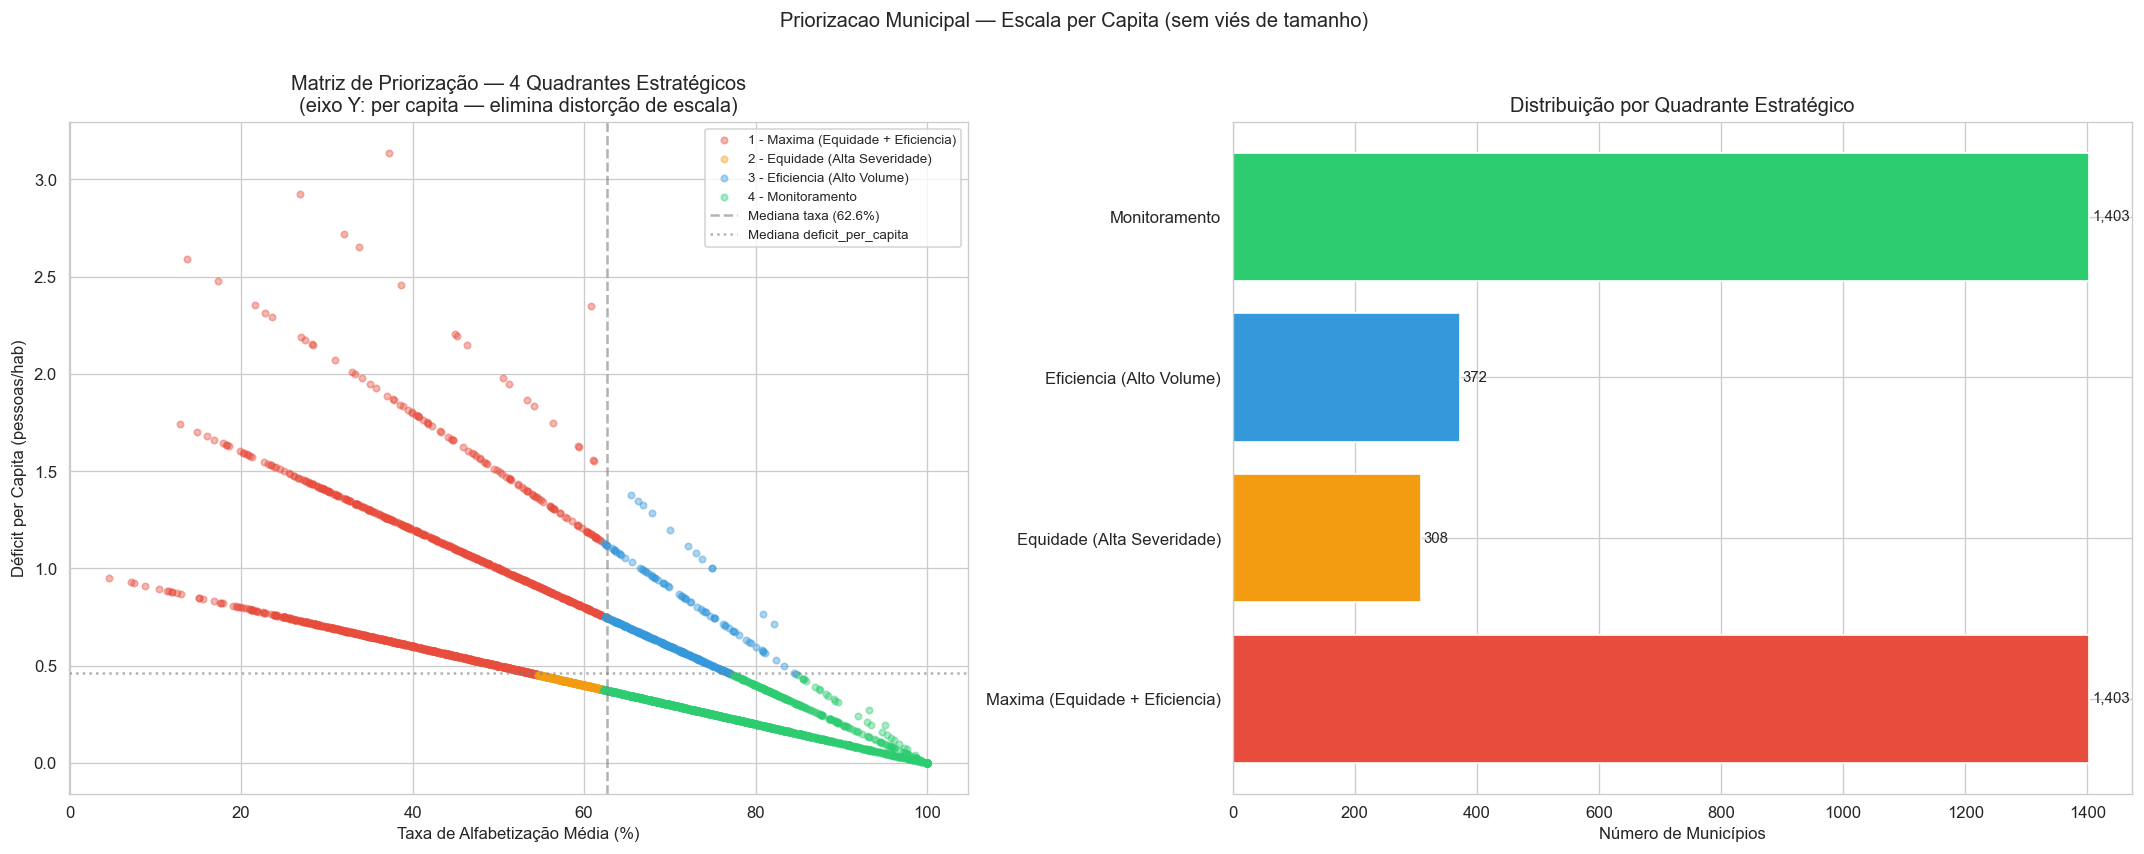

In [15]:
cores_q = {
    '1 - Maxima (Equidade + Eficiencia)': '#e74c3c',
    '2 - Equidade (Alta Severidade)': '#f39c12',
    '3 - Eficiencia (Alto Volume)': '#3498db',
    '4 - Monitoramento': '#2ecc71'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Eixo Y: deficit_per_capita elimina viés de escala
# (deficit_absoluto_proxy / populacao — cidades grandes não dominam o gráfico)
y_col = 'deficit_per_capita' if 'deficit_per_capita' in pdf_mz.columns else 'deficit_absoluto_proxy'
y_label = 'Déficit per Capita (pessoas/hab)' if y_col == 'deficit_per_capita' else 'Déficit Absoluto (M)'
y_scale = 1 if y_col == 'deficit_per_capita' else 1e6

for quad, group in pdf_mz.groupby('quadrante'):
    axes[0].scatter(group['taxa_alfabetizacao_media'], group[y_col] / y_scale,
                    alpha=0.4, s=15, label=quad, color=cores_q.get(quad, 'gray'))

mediana_taxa = pdf_mz['taxa_alfabetizacao_media'].median()
mediana_y = pdf_mz[y_col].median() / y_scale
axes[0].axvline(mediana_taxa, color='gray', linestyle='--', alpha=0.6, label=f'Mediana taxa ({mediana_taxa:.1f}%)')
axes[0].axhline(mediana_y, color='gray', linestyle=':', alpha=0.6, label=f'Mediana {y_col}')
axes[0].set_xlabel('Taxa de Alfabetização Média (%)')
axes[0].set_ylabel(y_label)
axes[0].set_title('Matriz de Priorização — 4 Quadrantes Estratégicos\n(eixo Y: per capita — elimina distorção de escala)')
axes[0].legend(fontsize=8)

# G2: distribuição por quadrante
q_counts = pdf_mz['quadrante'].value_counts().sort_index()
cores_bar = [cores_q.get(q, 'gray') for q in q_counts.index]
axes[1].barh(range(len(q_counts)), q_counts.values, color=cores_bar, edgecolor='white')
axes[1].set_yticks(range(len(q_counts)))
axes[1].set_yticklabels([q.split(' - ')[1] if ' - ' in q else q for q in q_counts.index], fontsize=10)
axes[1].set_xlabel('Número de Municípios')
axes[1].set_title('Distribuição por Quadrante Estratégico')

for i, v in enumerate(q_counts.values):
    axes[1].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Priorizacao Municipal — Escala per Capita (sem viés de tamanho)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


---
## Mart 6: agg_top10_uf — Acao por Estado

Cada gestor estadual recebe os 10 municipios prioritarios do seu estado.

In [16]:
pdf_t10 = spark.read.parquet(os.path.join(gold_dir, 'agg_top10_uf')).toPandas()
pdf_t10['ano'] = pdf_t10['ano'].astype(int)
print(f'Total: {len(pdf_t10)} municipios (10 por UF x 25 UFs)')
print('\nExemplo: Top 10 de SP (2024):')
pdf_t10[(pdf_t10['sigla_uf']=='SP') & (pdf_t10['ano']==2024)][['rank_uf','nome_municipio','taxa_alfabetizacao','status_risco','score_prioridade']]

Total: 487 municipios (10 por UF x 25 UFs)

Exemplo: Top 10 de SP (2024):


,rank_uf,nome_municipio,taxa_alfabetizacao,status_risco,score_prioridade
229,1,Taiaçu,38.71,4 - Risco Critico (Abaixo de 75%),0.3898
230,2,Cruzália,47.06,4 - Risco Critico (Abaixo de 75%),0.3623
231,3,Miguelópolis,29.09,3 - Risco Moderado (Acao Necessaria),0.3620
232,4,Arapeí,37.41,3 - Risco Moderado (Acao Necessaria),0.3081
233,5,Jumirim,50.81,4 - Risco Critico (Abaixo de 75%),0.3027
234,6,Coronel Macedo,38.69,3 - Risco Moderado (Acao Necessaria),0.2850
235,7,Oriente,39.53,3 - Risco Moderado (Acao Necessaria),0.2642
236,8,Itaju,44.34,3 - Risco Moderado (Acao Necessaria),0.2613
237,9,Cosmorama,56.46,3 - Risco Moderado (Acao Necessaria),0.2589
238,10,Pirapora do Bom Jesus,40.79,2 - Risco Leve (Atencao),0.2473


---
# Resumo Economico — Portfolio do Economista

## Os 3 Numeros Que Definem o Problema

| Indicador | Valor | O que significa |
|-----------|-------|-----------------|
| **Custo da Ineficiencia** | R$ 13,64 bilhoes | Desperdicio anual dos municipios que gastam acima do benchmark e alfabetizam abaixo da media |
| **Investimento Necessario** | R$ 865,7 milhoes | Custo para levar TODOS os 2.830 municipios abaixo de 80% a 80% de alfabetizacao |
| **Relacao Custo-Beneficio** | 15,8x | Cada R$1 investido em eficiencia libera R$15,8 de desperdicio realocavel |

>**Nota de rigor:** valores recalculados em 2026-07-06 após corrigir bug de unidade no benchmark SICONFI (`custo_por_ponto_alfabetizacao` usava despesa TOTAL do município em vez de gasto per capita — inflava o investimento em ~12.000x). Modelo agora consistente com **custo marginal per capita** (ver `docs/adr/ADR-012`, `docs/adr/ADR-013`) e com o pipeline cloud (`dataproc_04_siconfi.py`). Amostra local (3.486 municípios) — produção GCP com 5.550 municípios tem escala maior (ver `docs/NUMEROS_RECALCULADOS.md`: R$1.218,3M investimento, R$34,96bi desperdício, 28,69x).

## Recomendacoes de Politica Publica

1. **Nao e falta de recurso — e ineficiencia de gestao:** 1.843 municipios (53%) gastam acima da mediana mas alfabetizam abaixo. O problema nao e orcamento, e alocacao.
2. **O desperdicio cobre o investimento:** o valor desperdicado por ineficiencia supera em muito o custo de levar todos a 80%.
3. **Priorizar por eficiencia marginal:** o investimento deve ir para municipios Subinvestidos (495), nao para os Ineficientes (1.843). Os Ineficientes precisam de gestao, nao de dinheiro.
4. **Desigualdade regional persiste:** UFs do Nordeste concentram os piores indicadores. A transferencia fiscal equalizadora (FUNDEB) precisa considerar nao apenas populacao, mas eficiencia do gasto.

## Por que isso e um Portfolio de Economista?

- **Rigor metodologico:** pipeline medalhao (Bronze → Silver → Gold) com 114 testes unitarios
- **Raciocinio economico:** custo de oportunidade, eficiencia marginal, analise custo-beneficio
- **Traducao em R$:** nao ficamos em percentuais — calculamos o valor em reais da ineficiencia
- **Relevancia de politica publica:** dados reais (IBGE, INEP, SICONFI) e recomendacoes acionaveis
- **Tecnologia:** PySpark, K-Means + RandomForest, KNN imputation, SICONFI API, streaming, pipeline completo